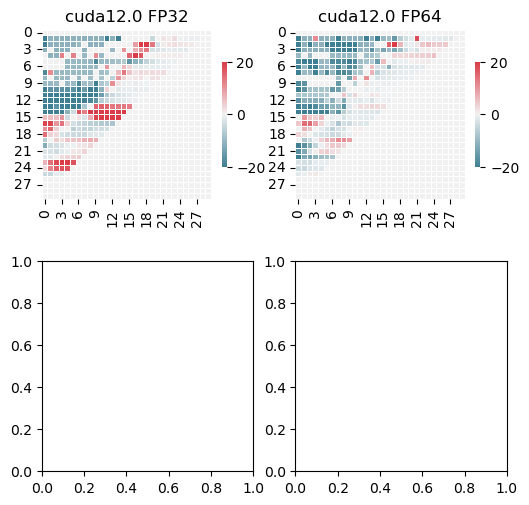

In [114]:
import torch as th
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from random import randint
from utils import load_data, load_data_single
import seaborn as sns

# filename = ['../data_0810/benchmark_cufft_A100_fp32.csv', '../data_0810/benchmark_turbofft_A100_fp32.csv']
filenames = [
        # ['../data_0810/benchmark_cufft_A100_fp32.csv', '../data_0810/benchmark_turbofft_A100_fp32.csv'],
        # ['../data_0810/benchmark_cufft_A100_fp64.csv', '../data_0810/benchmark_turbofft_A100_fp64.csv'],
        # ['../data_0810/cuFFT_fp32_cuda_12.0.csv', '../data_0810/turboFFT_fp32_cuda_12.0.csv'],
        ['../data_0810/cuFFT_fp32_cuda_12.0.csv', '../data_0810//turboFFT_fp32_cuda_12.0_40GB_28.csv'],
        ['../data_0810/cuFFT_fp64_cuda_12.0.csv', '../data_0810/turboFFT_fp64_cuda_12.0.csv'],

        # ['../data_0810/cuFFT_fp32_cuda_12.0_40GB_9.csv', '../data_0810/turboFFT_fp32_cuda_12.0_40GB_28.csv'],
]
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
for j in range(2):
    filename = filenames[j]
    cuFFT = th.ones(30, 30)
    TurboFFT = th.ones(30, 30)

    f_cufft = open(filename[0], 'r')
    f_TurboFFT = open(filename[1], 'r')

    lines_cufft = f_cufft.readlines()
    lines_TurboFFT = f_TurboFFT.readlines()

    for i in range(len(lines_cufft)):
        if lines_cufft[i].split(',')[0] != 'cuFFT' and lines_cufft[i].split(',')[0] != 'turboFFT':
        # if lines_TurboFFT[i].split(',')[0] != 'turboFFT':
            continue
        cuFFT[int(lines_cufft[i].split(',')[1])][int(lines_cufft[i].split(',')[2])] = float(lines_cufft[i].split(',')[3])

    # if j == 
    for i in range(len(lines_TurboFFT)):
        if lines_TurboFFT[i].split(',')[0] != 'turboFFT':
            continue
        TurboFFT[int(lines_TurboFFT[i].split(',')[1])][int(lines_TurboFFT[i].split(',')[2])] = float(lines_TurboFFT[i].split(',')[3])

    # print(TurboFFT[25], cuFFT[25])

    # Plotting the heatmap
    # plt.figure(figsize=(8, 6))
    # plt.imshow(TurboFFT/cuFFT, cmap='viridis')
    # plt.colorbar()
    # plt.title('Heatmap of a 30x30 Torch Tensor')
    # plt.show()
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns_plot = sns.heatmap((TurboFFT/cuFFT) * 100 - 100, cmap=cmap, vmax=20, vmin=-20,center=0,
    # sns_plot = sns.heatmap(TurboFFT/cuFFT * 100 - 100, cmap=cmap,center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[j // 2][j % 2],)
    ax[j//2][j % 2].set_title(f'cuda12.{j//2 * 2} FP{32+32*(j%2)}')
    # print(TurboFFT/cuFFT)

In [178]:
import torch as th
TurboFFT = th.ones(2, 30, 30)
TurboFFT *= 1e6
for i in range(30):
    filename = f'../data_0810/turboFFT_fp32_cuda_12.0_40GB_{i}.csv'
    try:
        f = open(filename, 'r')
    except:
        print('Cannot open file:', filename)
        continue
    lines = f.readlines()
    for line in lines:
        if line.split(',')[0] != 'turboFFT':
            continue
        logN = int(line.split(',')[1])
        logBS = int(line.split(',')[2])
        exec_time = float(line.split(',')[3])
        # if exec_time >= 0.1 * TurboFFT[logN][logBS]:
        if (i == 8 or i == 12) and logN == 13:
            continue
        TurboFFT[0][logN][logBS] = min(TurboFFT[0][logN][logBS], exec_time)
        # if logN==14 and logBS==10:
        #     print(i, exec_time)
        # print(TurboFFT[13][10], i)
filename = '../data_0810/turboFFT_fp64_cuda_12.0.csv'
f = open(filename, 'r')
lines = f.readlines()
    
for line in lines:
    if line.split(',')[0] != 'turboFFT':
        continue
    logN = int(line.split(',')[1])
    logBS = int(line.split(',')[2])
    exec_time = float(line.split(',')[3])
    TurboFFT[1][logN][logBS] = exec_time

TurboFFT[TurboFFT == 1e6] = 1

th.save(TurboFFT, '../data_0810/TurboFFT.pt')


Cannot open file: ../data_0810/turboFFT_fp32_cuda_12.0_40GB_0.csv


In [179]:
filenames = ['../data_0810/cuFFT_fp32_cuda_12.0_40GB.csv',
            '../data_0810/cuFFT_fp64_cuda_12.0.csv']
cuFFT = th.ones(2, 30, 30)
for p in range(2):
    filename = filenames[p]
    f = open(filename, 'r')
    lines_cufft = f.readlines()
    for i in range(len(lines_cufft)):
        if lines_cufft[i].split(',')[0] != 'cuFFT':
            continue
        cuFFT[p][int(lines_cufft[i].split(',')[1])][int(lines_cufft[i].split(',')[2])] = float(lines_cufft[i].split(',')[3])
        
th.save(cuFFT,'../data_0810/cuFFT.pt')

C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_18404\703662979.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')
C:\Users\SHIXUNW

torch.Size([2, 30, 30])


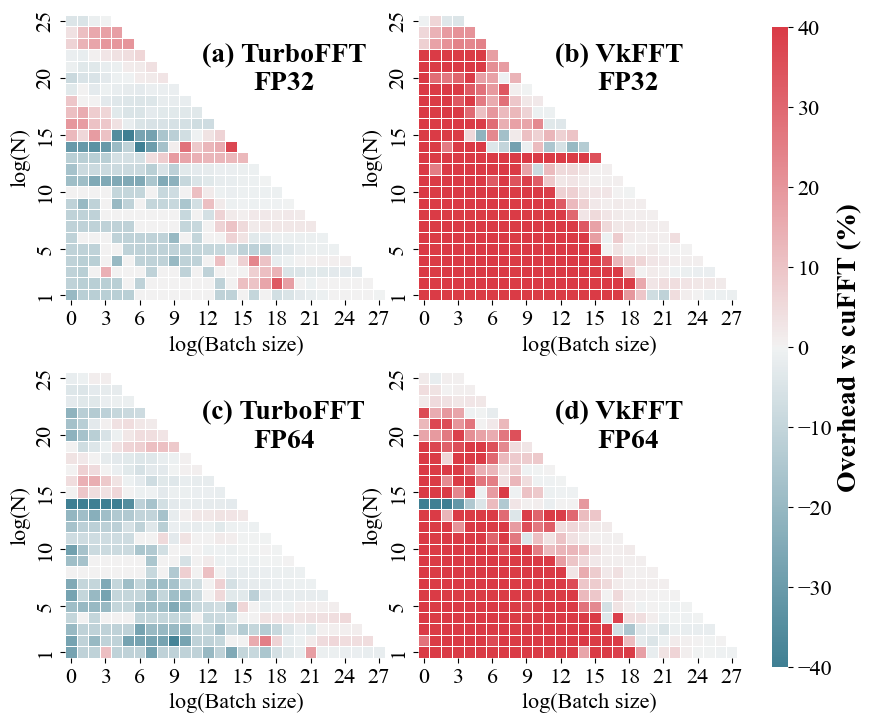

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 28
cuFFT = th.load('../data_0810/cuFFT.pt')
TurboFFT = th.load('../data_0810/turboFFT.pt')
vkFFT = th.load('../data_0810/vkFFT.pt')

fig, ax = plt.subplots(2, 2, figsize=(8, 8),)
fig.tight_layout()
fig.subplots_adjust(hspace=0, wspace=0.03)
bd = 40
print(cuFFT.shape)
mask = th.ones(30, 30)
for i in range(26):
        mask[i][:28-i+1] = 0
mask = mask.numpy()
mask = mask[1:26]
label = [
    '(a) TurboFFT',
    '(b) VkFFT',
    '(c) TurboFFT',
    '(d) VkFFT',
]
precision = ['FP32', 'FP64']
cbar_ax = fig.add_axes([.96, .1, .02, .8], label='Overhead vs cuFFT (%)')
for i in range(2):
	heatmap = (TurboFFT[i]/cuFFT[i])[1:26] * 100 - 100
	sns_plot = sns.heatmap(heatmap, cmap=cmap,  mask=mask, vmax=bd, vmin=-bd,center=0,
	# sns_plot = sns.heatmap((TurboFFT[i]/cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
			square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 0],cbar=False)
	# print(vkFFT[:30, :30].shape)
	heatmap = (vkFFT[i]/cuFFT[i])[1:26] * 100 - 100
	sns_plot = sns.heatmap(heatmap, cmap=cmap, mask=mask, vmax=bd, vmin=-bd,center=0,
	# sns_plot = sns.heatmap((vkFFT[i] / cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
			square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 1],
			cbar_ax=cbar_ax if i == 0 else None, cbar=i == 0)
	ax[i, 0].invert_yaxis()
	ax[i, 1].invert_yaxis()
cbar_ax.set_ylabel('Overhead vs cuFFT (%)', fontdict={'fontsize': fontsize, 'weight': 'bold'})
# fig.colorbar(ax.get_children()[0], orientation="horizontal")

for i in range(2):
	b = 0.1
	ax[i, 0].text(.3 + b, .9, label[i * 2], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	ax[i, 1].text(.3 + b, .9, label[i * 2 + 1], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	ax[i, 0].text(.45 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	ax[i, 1].text(.425 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	for j in range(2):
		b = 0.5
		ax[i, j].set_yticks([0 + b, 4 + b, 9+ b, 14+ b, 19+ b, 24+ b])
		ax[i, j].set_yticklabels([1, 5, 10, 15, 20, 25])
		ax[i, j].set_xticks([i + b for i in range(0, 28, 3)])
		ax[i, j].set_xticklabels([i for i in range(0, 28, 3)])
		
		ax[i, j].set_ylabel('log(N)')
		ax[i, j].set_xlabel('log(Batch size)')

plt.savefig('../figs/TurboFFT_vs_VkFFT_vs_cuFFT.pdf', bbox_inches='tight')

C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_2272\3609009510.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
C:\Us

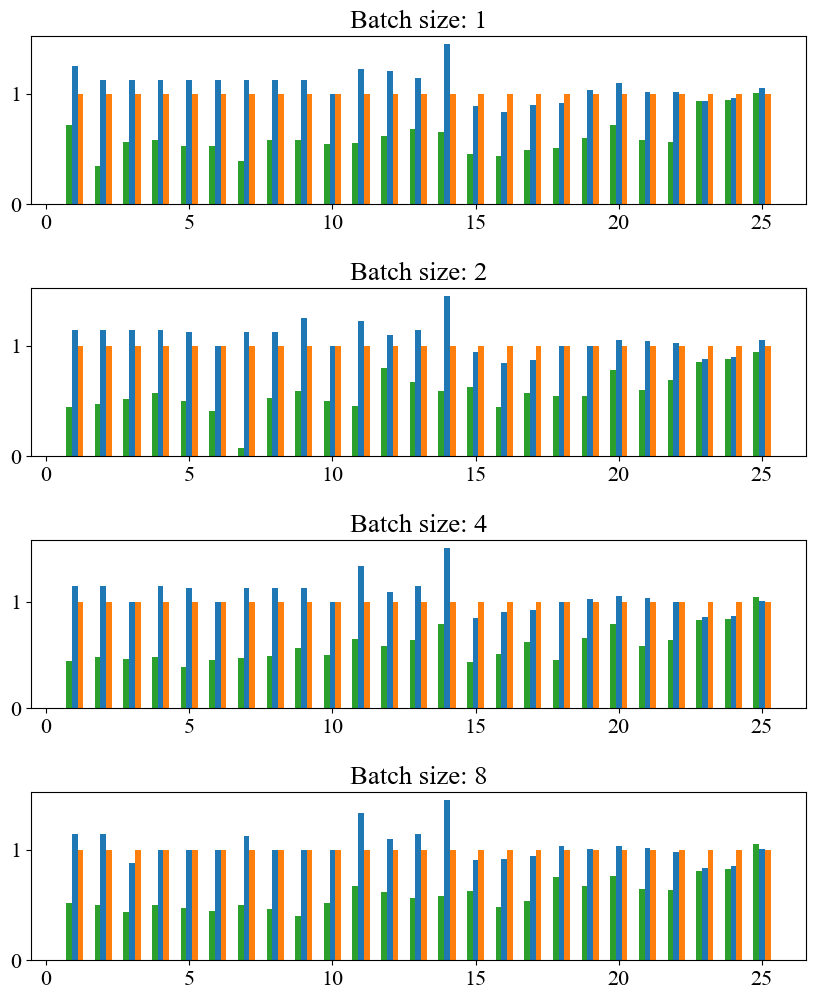

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import numpy as np
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 4
precision = 0
cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
TurboFFT = th.load('../data_0810/turboFFT.pt')[precision]
vkFFT = th.load('../data_0810/vkFFT.pt')[precision]
fig, ax = plt.subplots(logBS_end, 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.5, wspace=0.03)
color = sns.color_palette(n_colors=5)
# ax.plot(TurboFFT[1:,1], label='TurboFFT')
# ax.plot(cuFFT[1:,1], label='cuFFT')
# ax.plot(TurboFFT[1:, 1] / cuFFT[1:,1]

width = 0.2
for i in range(logBS_end):
    x_end = 26 
    x = np.arange(1,x_end)
    select_bs = i
    turboFFT_bar =  cuFFT[1:x_end,select_bs] / TurboFFT[1:x_end, select_bs]
    ax[i].bar(x, width=width, height=turboFFT_bar, color=color[0])
    ax[i].bar(x + width, width=width, height=cuFFT[1:x_end, select_bs] / cuFFT[1:x_end,select_bs], color=color[1])
    ax[i].bar(x - width, width=width, height=cuFFT[1:x_end, select_bs] / vkFFT[1:x_end,select_bs], color=color[2])
    ax[i].set_title(f'Batch size: {2**select_bs}')
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[0][i, 28 - i] for i in range(1, x_end)]
# select_bs = 
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[i, 28 - i] for i in range(1, x_end)]
# ax[1].bar(x, width=width, height=turboFFT_bar, color=color[0])
# ax[1].bar(x + width, width=width, height=cuFFT_bar, color=color[1])
# ax[1].bar(x - width, width=width, height=vkfft_bar, color=color[2])


C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_2272\3871849201.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
C:\Us

torch.Size([30]) (30,)
torch.Size([30]) (30,)
torch.Size([30]) (30,)
torch.Size([30]) (30,)


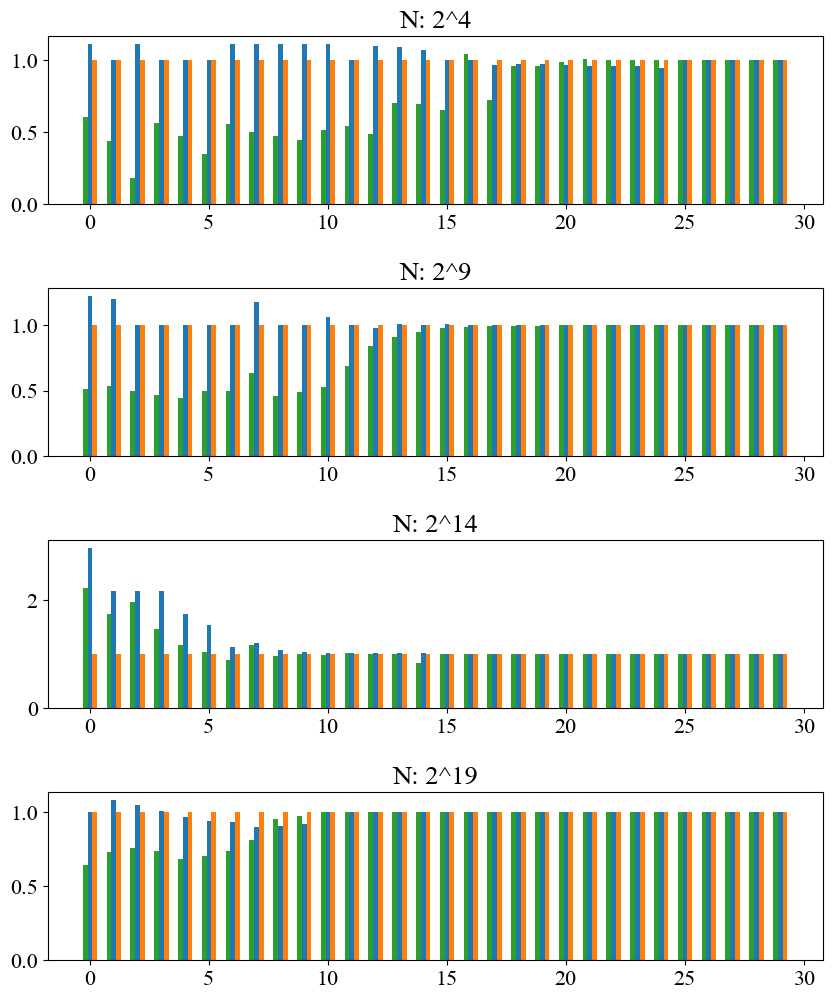

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import numpy as np
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 4
precision = 1
cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
TurboFFT = th.load('../data_0810/turboFFT.pt')[precision]
vkFFT = th.load('../data_0810/vkFFT.pt')[precision]

N_list = [4, 9, 14, 19]
fig, ax = plt.subplots(len(N_list), 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.5, wspace=0.03)
color = sns.color_palette(n_colors=5)
# ax.plot(TurboFFT[1:,1], label='TurboFFT')
# ax.plot(cuFFT[1:,1], label='cuFFT')
# ax.plot(TurboFFT[1:, 1] / cuFFT[1:,1]

width = 0.2
for i, N in enumerate(N_list):
    begin = 0
    end = 30
    x = np.arange(begin,end)
    select_n = N
    turboFFT_bar =  cuFFT[select_n][begin:end] / TurboFFT[select_n][begin:end]
    print(turboFFT_bar.shape, x.shape)
    ax[i].bar(x, width=width, height=turboFFT_bar, color=color[0])
    ax[i].bar(x + width, width=width, height=cuFFT[select_n][begin:end] / cuFFT[select_n][begin:end], color=color[1])
    ax[i].bar(x - width, width=width, height=cuFFT[select_n][begin:end] / vkFFT[select_n][begin:end], color=color[2])
    ax[i].set_title(f'N: 2^{select_n}')
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[0][i, 28 - i] for i in range(1, x_end)]
# select_bs = 
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[i, 28 - i] for i in range(1, x_end)]
# ax[1].bar(x, width=width, height=turboFFT_bar, color=color[0])
# ax[1].bar(x + width, width=width, height=cuFFT_bar, color=color[1])
# ax[1].bar(x - width, width=width, height=vkfft_bar, color=color[2])
